# 3. AR VTO Create PCA Feature List

### Change Log

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
#read csv file

df_survey_cleaned = pd.read_csv('df_survey_cleaned.csv')

In [3]:
#display column headers and the first row

df_survey_cleaned.head(2)

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,...,HMPU_centered_squared,HMPU_centered_cubed,HMPEOU_centered_squared,HMPEOU_centered_cubed,HMSOI_centered_squared,HMSOI_centered_cubed,HMSEI_centered_squared,HMSEI_centered_cubed,HMPE_centered_squared,HMPE_centered_cubed
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,...,0.005502,-0.000408,0.001576,0.000063,0.008683,-0.000809,0.008909,-0.000841,0.000717,0.000019
1,13/10/2022 13:29:22,3.0,3.0,3.0,Mua sắm,3.0,3.0,3.0,3.0,3.0,...,0.506365,0.360325,0.365972,0.221397,0.385454,0.239309,0.395492,0.248717,0.477600,0.330062


In [4]:

feature_vars = [
 
    'PU_centered', 'PEOU_centered', 'PE_centered', 'HM_centered', 'SOI_centered', 'SEI_centered', 'PPV_centered',
    'PEAT_centered', 'HMAT_centered', 'HMPU_centered', 'HMPEOU_centered', 'HMSOI_centered', 'HMSEI_centered', 'HMPE_centered',
    'AGEGender_centered', 'GenderPU_centered', 'GenderPEOU_centered', 'GenderAT_centered', 'GenderPPV_centered',
    'GenderPE_centered', 'GenderHM_centered', 'GenderSOI_centered', 'GenderSEI_centered', 'AGEPEOU_centered', 'AGEPU_centered',
    'AGESOI_centered', 'AGESEI_centered', 'AGEPPV_centered', 'AGEHM_centered', 'AGEPE_centered', 'AGEAT_centered',
    'SOI_centered_squared', 'SEI_centered_squared',
    'HM_centered_squared', 'AT_centered_squared', 'PPV_centered_squared', 
    'PU_centered_squared',  'PEOU_centered_squared', 
    'AGEGender_centered_squared',  'GenderPU_centered_squared', 
    'GenderPEOU_centered_squared', 'GenderAT_centered_squared', 
    'GenderPPV_centered_squared',  'GenderPE_centered_squared', 
    'GenderHM_centered_squared', 'GenderSOI_centered_squared', 
    'GenderSEI_centered_squared', 'AGEPEOU_centered_squared', 
    'AGEPU_centered_squared',  'AGESOI_centered_squared', 
    'AGESEI_centered_squared', 'AGEPPV_centered_squared', 
    'AGEHM_centered_squared',  'PEAT_centered_squared', 
    'HMAT_centered_squared', 'HMPU_centered_squared', 
    'HMPEOU_centered_squared',  'HMSOI_centered_squared', 
    'HMSEI_centered_squared', 'HMPE_centered_squared', 'AGE_num', 'Gender_num'

]

# Select the subset of the DataFrame, excluding the target variable
df_subset = df_survey_cleaned[feature_vars]

df_subset

,PU_centered,PEOU_centered,PE_centered,HM_centered,SOI_centered,SEI_centered,PPV_centered,PEAT_centered,HMAT_centered,HMPU_centered,...,AGEHM_centered_squared,PEAT_centered_squared,HMAT_centered_squared,HMPU_centered_squared,HMPEOU_centered_squared,HMSOI_centered_squared,HMSEI_centered_squared,HMPE_centered_squared,AGE_num,Gender_num
0,-0.568396,0.304245,0.205189,0.130503,-0.714033,-0.723270,0.211478,-0.034198,-0.021751,-0.074177,...,0.153280,0.001170,0.000473,0.005502,0.001576,0.008683,0.008909,0.000717,3,0
1,-0.818396,-0.695755,-0.794811,-0.869497,-0.714033,-0.723270,-0.788522,0.662343,0.724581,0.711593,...,0.756025,0.438698,0.525017,0.506365,0.365972,0.385454,0.395492,0.477600,1,1
2,0.181604,0.304245,0.205189,0.130503,0.285967,0.276730,0.211478,0.034198,0.021751,0.023700,...,0.153280,0.001170,0.000473,0.000562,0.001576,0.001393,0.001304,0.000717,3,0
3,0.181604,0.304245,0.705189,1.130503,0.035967,-1.389937,0.211478,0.117531,0.188417,0.205304,...,1.278037,0.013814,0.035501,0.042150,0.118302,0.001653,2.469073,0.635557,1,0
4,-0.318396,0.304245,-0.794811,0.130503,-0.464033,-0.723270,0.211478,-0.132469,0.021751,-0.041552,...,0.017031,0.017548,0.000473,0.001727,0.001576,0.003667,0.008909,0.010759,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,0.931604,0.637579,0.705189,1.130503,1.035967,0.943396,0.544811,0.822720,1.318920,1.053181,...,11.502336,0.676868,1.739551,1.109190,0.519530,1.371625,1.137449,0.635557,3,1
420,0.431604,0.970912,0.455189,0.797170,1.035967,1.276730,0.544811,0.227594,0.398585,0.344061,...,5.719317,0.051799,0.158870,0.118378,0.599048,0.682014,1.035856,0.131669,3,1
421,0.681604,-0.029088,0.205189,0.797170,0.535967,1.276730,0.878145,0.102594,0.398585,0.543354,...,5.719317,0.010526,0.158870,0.295234,0.000538,0.182548,1.035856,0.026755,3,1
422,0.681604,-0.029088,0.205189,0.797170,0.535967,1.276730,0.878145,0.102594,0.398585,0.543354,...,5.719317,0.010526,0.158870,0.295234,0.000538,0.182548,1.035856,0.026755,3,1


C:\Users\cemcd\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


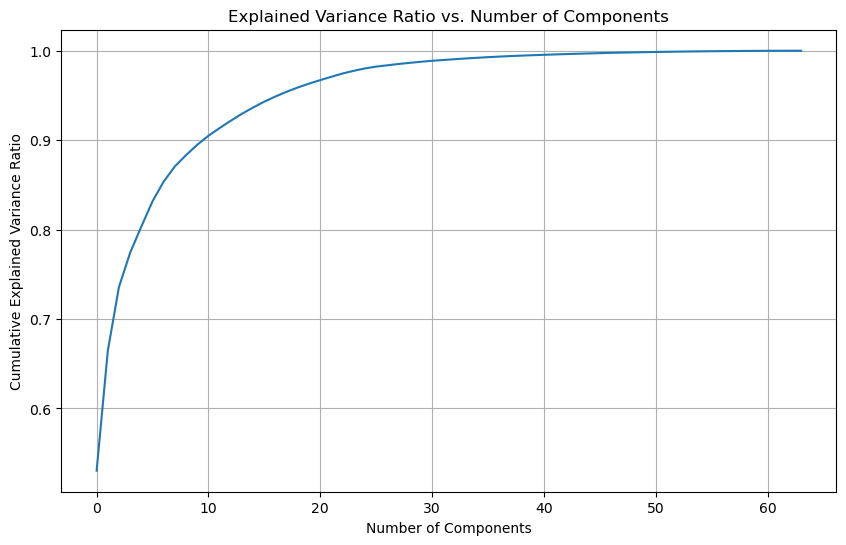

PC1: 0.5303
PC2: 0.1342
PC3: 0.0715
PC4: 0.0382
PC5: 0.0293
PC6: 0.0283
PC7: 0.0220
PC8: 0.0169
PC9: 0.0126
PC10: 0.0115
PC11: 0.0101
PC12: 0.0086
PC13: 0.0082
PC14: 0.0078
PC15: 0.0070
PC16: 0.0066
PC17: 0.0058
PC18: 0.0053
PC19: 0.0048
PC20: 0.0043
PC21: 0.0039
PC22: 0.0038
PC23: 0.0036
PC24: 0.0030
PC25: 0.0027
PC26: 0.0020
PC27: 0.0015
PC28: 0.0015
PC29: 0.0013
PC30: 0.0012
PC31: 0.0011
PC32: 0.0009
PC33: 0.0009
PC34: 0.0008
PC35: 0.0008
PC36: 0.0007
PC37: 0.0006
PC38: 0.0006
PC39: 0.0005
PC40: 0.0005
PC41: 0.0004
PC42: 0.0004
PC43: 0.0004
PC44: 0.0004
PC45: 0.0004
PC46: 0.0003
PC47: 0.0003
PC48: 0.0003
PC49: 0.0003
PC50: 0.0002
PC51: 0.0002
PC52: 0.0002
PC53: 0.0002
PC54: 0.0002
PC55: 0.0002
PC56: 0.0001
PC57: 0.0001
PC58: 0.0001
PC59: 0.0001
PC60: 0.0001
PC61: 0.0001
PC62: 0.0000
PC63: 0.0000
PC64: 0.0000

Number of components to keep: 18

Transformed data (first few rows):
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.297775 -2.055506  0.914192 

C:\Users\cemcd\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import pandas as pd
pd.set_option('display.max_rows', None)

# Assuming df_survey_cleaned and feature_vars are already defined
# Select the subset of the DataFrame, excluding the target variable
df_subset = df_survey_cleaned[feature_vars]

# Separate the target variable (optional, in case you need it later)
target_variable = df_survey_cleaned['BI']

# Define categorical and numerical features
categorical_features = ['AGE_num', 'Gender_num']
numerical_features = df_subset.columns.drop(categorical_features).tolist()

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse=False), categorical_features)
    ])

# Create a pipeline that preprocesses the data and then performs PCA
pca_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA())
])

# Fit and transform the data
X_pca = pca_pipeline.fit_transform(df_subset)

# Get the PCA object
pca = pca_pipeline.named_steps['pca']

# Calculate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plot the cumulative explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Explained Variance Ratio vs. Number of Components')
plt.grid(True)
plt.show()

# Print the explained variance ratio for each component
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

# Choose the number of components to keep (e.g., 95% of variance explained)
n_components = np.argmax(np.cumsum(explained_variance_ratio) >= 0.95) + 1
print(f"\nNumber of components to keep: {n_components}")

# Perform PCA with the selected number of components
pca_final = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=n_components))
])

X_pca_final = pca_final.fit_transform(df_subset)

# Create a DataFrame with the transformed data
pca_df = pd.DataFrame(data=X_pca_final, columns=[f'PC{i+1}' for i in range(n_components)])

# Print the first few rows of the transformed data
print("\nTransformed data (first few rows):")
print(pca_df.head())

# Get feature names after preprocessing
numeric_feature_names = numerical_features
categorical_feature_names = pca_final.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
feature_names = numeric_feature_names + categorical_feature_names

# Print the loadings (feature weights for each principal component)
loadings = pd.DataFrame(
    pca_final.named_steps['pca'].components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=feature_names
)
print("\nPCA Loadings:")
print(loadings)

# Optionally, you can save the PCA results
pca_df.to_csv('pca_results.csv', index=False)
loadings.to_csv('pca_loadings.csv')

In [6]:
import numpy as np

# Get the loadings for the first 18 components
loadings = pca.components_[:8].T

# Calculate cumulative contributions
cumulative_contributions = np.sum(loadings**2, axis=1)

# Create a dictionary of feature contributions
feature_contributions = dict(zip(feature_names, cumulative_contributions))

# Sort features by contribution in descending order
sorted_features = sorted(feature_contributions.items(), key=lambda x: x[1], reverse=True)

# Print top contributing features
for feature, contribution in sorted_features:
    print(f"{feature}: {contribution}")

# Create a DataFrame
df_features = pd.DataFrame(sorted_features, columns=['Feature', 'Contribution'])

# Reset the index to start from 1
df_features.index = range(1, len(df_features) + 1)

# Optional: Format the 'Contribution' column to show fewer decimal places
df_features['Contribution'] = df_features['Contribution'].round(4)

# Display the first few rows of the DataFrame
print(df_features.head(50))

# Optional: Save the DataFrame to a CSV file
# df_features.to_csv('feature_contributions.csv', index=True)

AGEGender_centered_squared: 0.3874316405274706
AGEGender_centered: 0.3665907659099509
GenderPEOU_centered_squared: 0.25441388331514586
AGEPEOU_centered_squared: 0.24595359499672834
GenderPEOU_centered: 0.22827693920119174
AGESOI_centered_squared: 0.208825347104121
AGESEI_centered_squared: 0.20564451883821436
PEOU_centered_squared: 0.18663144961014932
AGEPEOU_centered: 0.18018045545451283
PEOU_centered: 0.1733550969572646
AGEPPV_centered_squared: 0.17189867527977543
GenderAT_centered: 0.1650247717310816
GenderSEI_centered: 0.16470818607111526
AGEHM_centered_squared: 0.1641975204544931
GenderPU_centered: 0.16017521379601968
GenderHM_centered: 0.15439311137707365
AGEPU_centered_squared: 0.15037182983402378
GenderAT_centered_squared: 0.14464171367453782
GenderPE_centered: 0.1434123319140055
GenderPE_centered_squared: 0.1433563931879055
GenderSEI_centered_squared: 0.14137488334400625
GenderPPV_centered: 0.14098372041603868
GenderSOI_centered: 0.13836850672056047
GenderSOI_centered_squared: 

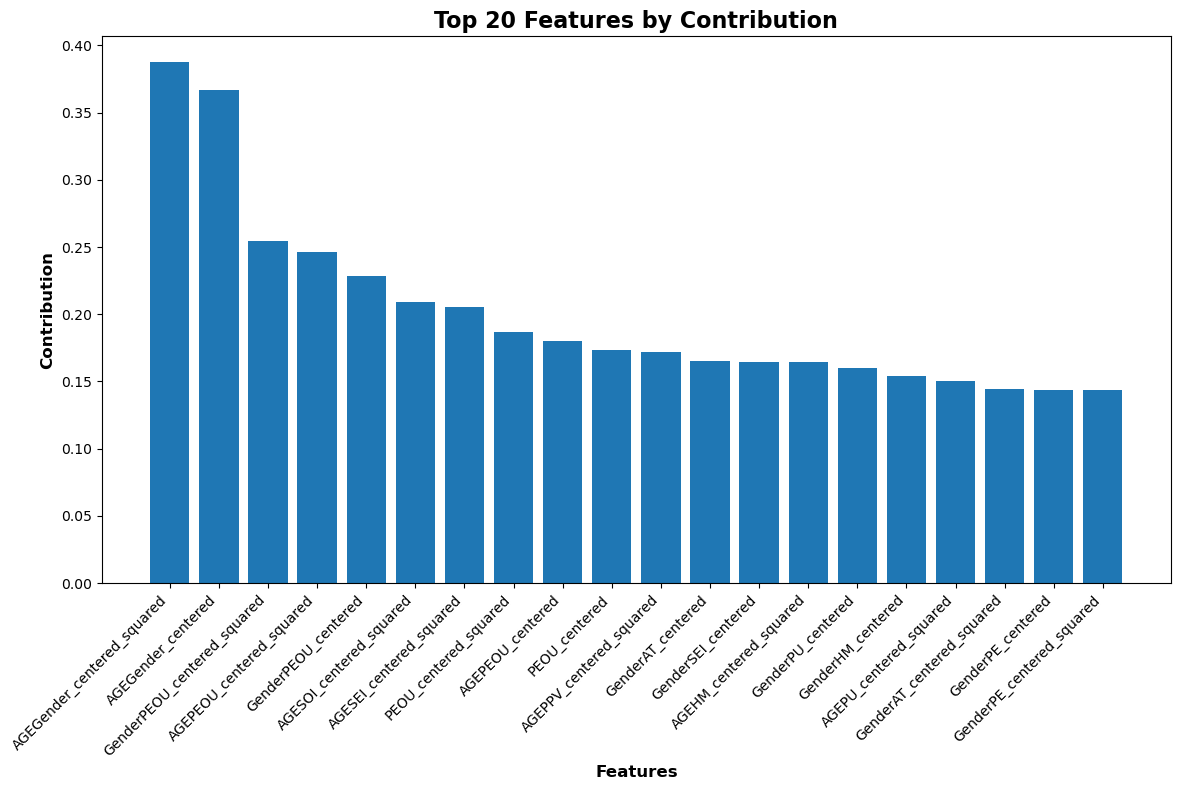

In [7]:
import matplotlib.pyplot as plt

# Sort the DataFrame by 'Contribution' in descending order and select top 15
top_15 = df_features[['Feature', 'Contribution']].sort_values('Contribution', ascending=False).head(20)

# Create the bar plot
plt.figure(figsize=(12, 8))
plt.bar(top_15['Feature'], top_15['Contribution'])

# Customize the plot
plt.title('Top 20 Features by Contribution', fontsize=16, fontweight='bold')
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Contribution', fontsize=12, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Show the plot
plt.show()

#### create json file

In [8]:
import pandas as pd
import json

# Assuming you already have df_features DataFrame

# Extract features into a list
feature_list = df_features['Feature'].tolist()

# Optionally, you might want to limit the number of features
# For example, to keep only the top 30 features:
# feature_list = df_features['Feature'].head(30).tolist()

# Create a dictionary with a key for the feature list
feature_dict = {"PCA_selected_features": feature_list}

# Write the dictionary to a JSON file
with open('PCA_selected_features.json', 'w') as json_file:
    json.dump(feature_dict, json_file, indent=2)

print(f"Selected features have been written to 'PCA_selected_features.json'")

# Optionally, print the first few features to verify
print("First few selected features:")
print(feature_list[:15])

Selected features have been written to 'PCA_selected_features.json'
First few selected features:
['AGEGender_centered_squared', 'AGEGender_centered', 'GenderPEOU_centered_squared', 'AGEPEOU_centered_squared', 'GenderPEOU_centered', 'AGESOI_centered_squared', 'AGESEI_centered_squared', 'PEOU_centered_squared', 'AGEPEOU_centered', 'PEOU_centered', 'AGEPPV_centered_squared', 'GenderAT_centered', 'GenderSEI_centered', 'AGEHM_centered_squared', 'GenderPU_centered']


In [9]:
print('End of Script')

End of Script
